#### Assignment 3
**Mahshid Bargahi**

This notebook explores the application of **Multi-Layer Perceptrons (MLPs)** for a supervised regression task using the Diamonds dataset. The objective is to predict diamond prices based on their physical and quality-related characteristics.



This classic dataset contains the prices and other attributes of almost 54,000 diamonds.
Content: 

price : price in US dollars 

carat : weight of the diamond 

cut : quality of the cut (Fair, Good, Very Good, Premium, Ideal)

color : diamond colour, from J (worst) to D (best)

clarity : a measurement of how clear the diamond is (I1 (worst), SI2, SI1, VS2, VS1, VVS2, VVS1, IF (best))

x : length in mm (0--10.74)

y : width in mm (0--58.9)

z : depth in mm (0--31.8)



## Import Libraries

In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Loading the dataset

In [7]:
data = pd.read_csv(r"D:\sharif\ADS\assignments\assignment3\MLP\Regression\diamonds.csv")

## Getting some insight frome data

In [ ]:
data.head()

,Unnamed: 0,carat,cut,color,clarity,depth,table,price,x,y,z
0,1,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,2,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,3,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,4,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,5,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


The 'Unnamed' column is like an ID column and its unnecessary , so we drop it. 

In [20]:
data.drop(columns=['Unnamed: 0'], inplace=True)
data.shape

(53940, 10)

In [21]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   carat    53940 non-null  float64
 1   cut      53940 non-null  object 
 2   color    53940 non-null  object 
 3   clarity  53940 non-null  object 
 4   depth    53940 non-null  float64
 5   table    53940 non-null  float64
 6   price    53940 non-null  int64  
 7   x        53940 non-null  float64
 8   y        53940 non-null  float64
 9   z        53940 non-null  float64
dtypes: float64(6), int64(1), object(3)
memory usage: 4.1+ MB


In [22]:
data.isnull().sum()

carat      0
cut        0
color      0
clarity    0
depth      0
table      0
price      0
x          0
y          0
z          0
dtype: int64

There is'nt any missing value in dataset.

In [23]:
data.duplicated().sum()

np.int64(146)

And there is'nt anu duplicated sample.

In [24]:
data.describe()

,carat,depth,table,price,x,y,z
count,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000
mean,0.797940,61.749405,57.457184,3932.799722,5.731157,5.734526,3.538734
std,0.474011,1.432621,2.234491,3989.439738,1.121761,1.142135,0.705699
min,0.200000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,0.400000,61.000000,56.000000,950.000000,4.710000,4.720000,2.910000
50%,0.700000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,1.040000,62.500000,59.000000,5324.250000,6.540000,6.540000,4.040000
max,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


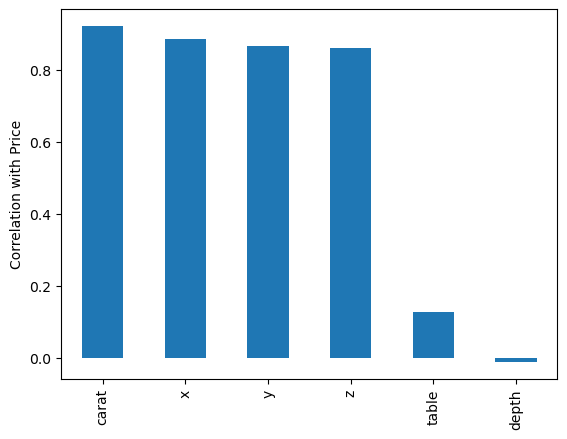

In [25]:
numeric_df = data.select_dtypes(include='number')

corr_with_price = numeric_df.corr()['price'].sort_values(ascending=False)

corr_with_price.drop('price').plot(kind='bar')
plt.ylabel('Correlation with Price')
plt.show()

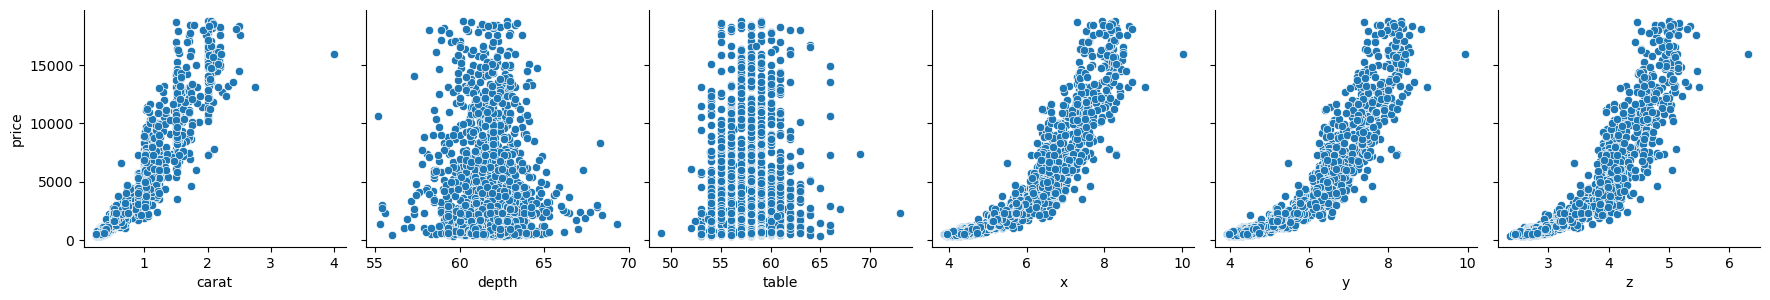

In [32]:
sample = data.sample(2000, random_state=42)

sns.pairplot(
    sample,
    x_vars=['carat', 'depth', 'table', 'x', 'y', 'z'],
    y_vars=['price'],
    height=3
)

plt.show()

As we see, caret has a linear relation with target. 

x, y, z has same relation.

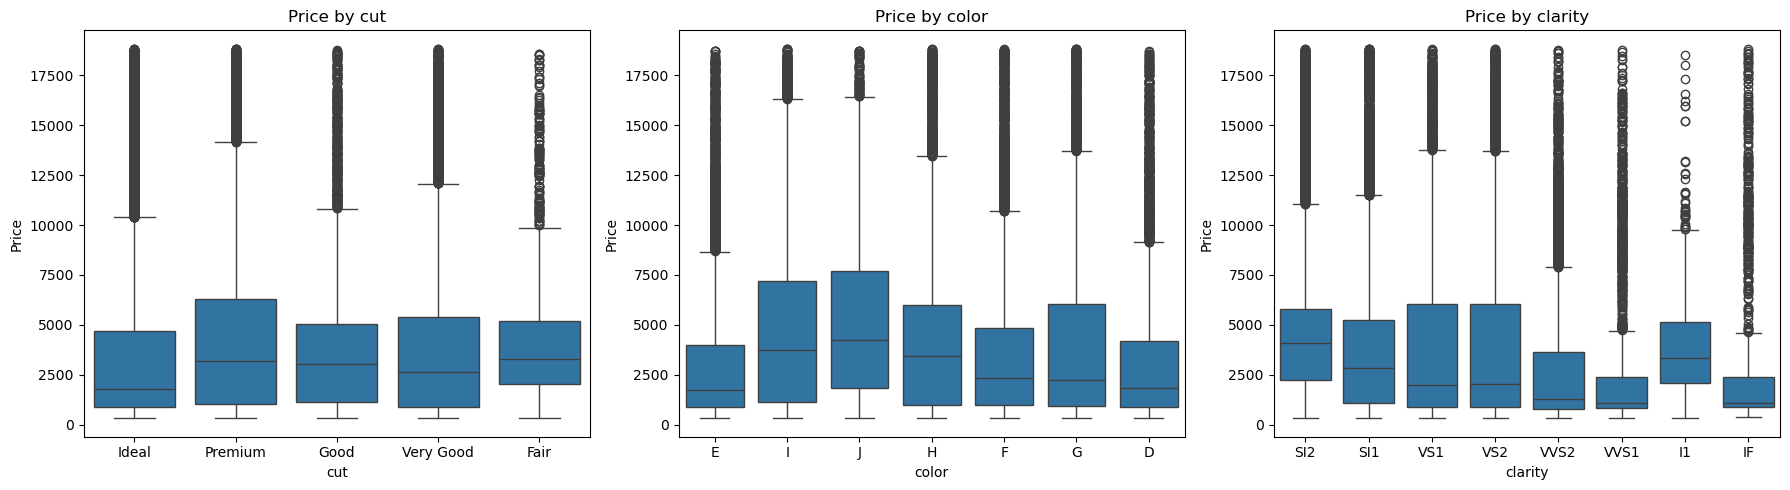

In [38]:
categorical_cols = ['cut', 'color', 'clarity']
fig, axes = plt.subplots(1, len(categorical_cols), figsize=(18, 5))

for ax, col in zip(axes, categorical_cols):
    sns.boxplot(data=data, x=col, y='price', ax=ax)
    ax.set_title(f'Price by {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Price')
    
plt.tight_layout()
plt.show()

The relationship between 'cut' and 'price' does not follow the expected quality ranking. 

This indicates that color grade is not the dominant factor affecting price and that other variables may be confounding this relationship.

Diamonds with lower clarity grades often show higher median prices than premium clarity grades .

This observation suggests that clarity alone does not determine price and that larger diamonds may be overrepresented in the lower-clarity categories.

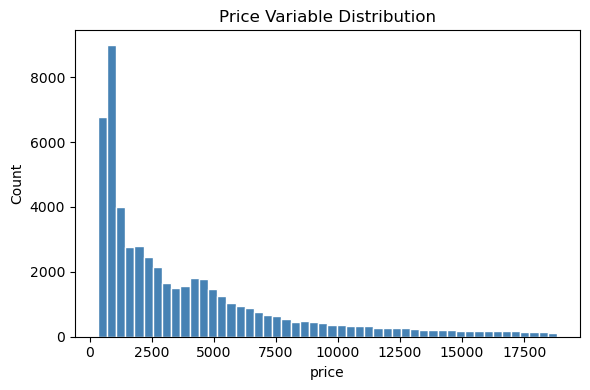

In [49]:
fig, ax = plt.subplots(figsize=(6, 4))

ax.hist(data['price'], bins=50, color='steelblue', edgecolor='white')
ax.set_title('Price Variable Distribution')
ax.set_xlabel('price')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

A highly skewed target distribution can make regression more challenging because large prices may dominate the loss function and increase prediction errors.

To address this issue, a logarithmic transformation of the target variable can be considered.

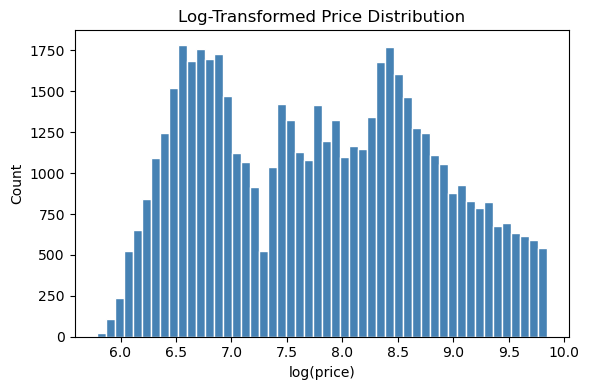

In [50]:
plt.figure(figsize=(6,4))
plt.hist(np.log1p(data['price']),bins=50, color='steelblue', edgecolor='white')
plt.title('Log-Transformed Price Distribution')
plt.xlabel('log(price)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

### Check invalid values in Dimensions

In [ ]:
data[(data[['x', 'y', 'z']] == 0).any(axis=1)]

,carat,cut,color,clarity,depth,table,price,x,y,z
2207,1.00,Premium,G,SI2,59.1,59.0,3142,6.55,6.48,0.0
2314,1.01,Premium,H,I1,58.1,59.0,3167,6.66,6.60,0.0
4791,1.10,Premium,G,SI2,63.0,59.0,3696,6.50,6.47,0.0
5471,1.01,Premium,F,SI2,59.2,58.0,3837,6.50,6.47,0.0
10167,1.50,Good,G,I1,64.0,61.0,4731,7.15,7.04,0.0
11182,1.07,Ideal,F,SI2,61.6,56.0,4954,0.00,6.62,0.0
11963,1.00,Very Good,H,VS2,63.3,53.0,5139,0.00,0.00,0.0
13601,1.15,Ideal,G,VS2,59.2,56.0,5564,6.88,6.83,0.0
15951,1.14,Fair,G,VS1,57.5,67.0,6381,0.00,0.00,0.0
24394,2.18,Premium,H,SI2,59.4,61.0,12631,8.49,8.45,0.0


Since a diamond cannot have a zero dimension, remove these rows.

In [ ]:
data = data[(data[['x', 'y', 'z']] != 0).all(axis=1)]
data.shape

(53920, 10)

##  Train / Test Split


In [44]:
X = data.drop('price', axis=1)
y = np.log1p(data['price']) # log-transform the target

In [53]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f'Train      : {X_train.shape[0]:>5} rows  ({X_train.shape[0]/len(X)*100:.0f}%)')
print(f'Test       : {X_test.shape[0]:>5} rows  ({X_test.shape[0]/len(X)*100:.0f}%)')

Train      : 43136 rows  (80%)
Test       : 10784 rows  (20%)


## Encode Categorical Features

We apply One-Hot Encoding to the categorical features (cut, color, and clarity).

In [54]:
X_train = pd.get_dummies(
    X_train,
    columns=['cut', 'color', 'clarity'],
    drop_first=True
)

X_test = pd.get_dummies(
    X_test,
    columns=['cut', 'color', 'clarity'],
    drop_first=True
)

# Ensure same columns in train and test
X_train, X_test = X_train.align(
    X_test,
    join='left',
    axis=1,
    fill_value=0
)

print(
    pd.get_dummies(
        data.drop('price', axis=1),
        columns=['cut', 'color', 'clarity'],
        drop_first=True
    ).columns
)

Index(['carat', 'depth', 'table', 'x', 'y', 'z', 'cut_Good', 'cut_Ideal',
       'cut_Premium', 'cut_Very Good', 'color_E', 'color_F', 'color_G',
       'color_H', 'color_I', 'color_J', 'clarity_IF', 'clarity_SI1',
       'clarity_SI2', 'clarity_VS1', 'clarity_VS2', 'clarity_VVS1',
       'clarity_VVS2'],
      dtype='object')


## Normalization/Stadardization


In [55]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [58]:
print(X_train.shape)
pd.DataFrame(X_train).describe()

(43136, 23)


,0,1,2,3,4,5,6,7,8,9,...,13,14,15,16,17,18,19,20,21,22
count,4.313600e+04,4.313600e+04,4.313600e+04,4.313600e+04,4.313600e+04,4.313600e+04,4.313600e+04,4.313600e+04,4.313600e+04,4.313600e+04,...,4.313600e+04,4.313600e+04,4.313600e+04,4.313600e+04,4.313600e+04,4.313600e+04,4.313600e+04,4.313600e+04,4.313600e+04,4.313600e+04
mean,-2.100199e-16,1.344622e-15,-3.669913e-15,-1.746048e-17,-4.826340e-16,6.885359e-17,-4.447481e-17,2.075491e-17,-3.409735e-17,3.195597e-17,...,2.927925e-17,-4.822222e-17,1.166228e-16,4.010969e-17,-8.400797e-18,3.722706e-17,2.075491e-17,4.579258e-17,1.037746e-17,8.091945e-18
std,1.000012e+00,1.000012e+00,1.000012e+00,1.000012e+00,1.000012e+00,1.000012e+00,1.000012e+00,1.000012e+00,1.000012e+00,1.000012e+00,...,1.000012e+00,1.000012e+00,1.000012e+00,1.000012e+00,1.000012e+00,1.000012e+00,1.000012e+00,1.000012e+00,1.000012e+00,1.000012e+00
min,-1.259706e+00,-1.312455e+01,-6.492304e+00,-1.786407e+00,-1.800327e+00,-3.565442e+00,-3.148307e-01,-8.148256e-01,-5.881301e-01,-5.373615e-01,...,-4.277937e-01,-3.359631e-01,-2.342018e-01,-1.855706e-01,-5.665347e-01,-4.507423e-01,-4.226626e-01,-5.407282e-01,-2.717774e-01,-3.226858e-01
25%,-8.379097e-01,-5.229021e-01,-6.549616e-01,-9.113450e-01,-8.885899e-01,-9.080222e-01,-3.148307e-01,-8.148256e-01,-5.881301e-01,-5.373615e-01,...,-4.277937e-01,-3.359631e-01,-2.342018e-01,-1.855706e-01,-5.665347e-01,-4.507423e-01,-4.226626e-01,-5.407282e-01,-2.717774e-01,-3.226858e-01
50%,-2.052147e-01,3.717127e-02,-2.059352e-01,-3.628297e-02,-2.068618e-02,-2.702980e-02,-3.148307e-01,-8.148256e-01,-5.881301e-01,-5.373615e-01,...,-4.277937e-01,-3.359631e-01,-2.342018e-01,-1.855706e-01,-5.665347e-01,-4.507423e-01,-4.226626e-01,-5.407282e-01,-2.717774e-01,-3.226858e-01
75%,5.118396e-01,5.272355e-01,6.921174e-01,7.226994e-01,7.069503e-01,7.239801e-01,-3.148307e-01,1.227256e+00,1.700304e+00,-5.373615e-01,...,-4.277937e-01,-3.359631e-01,-2.342018e-01,-1.855706e-01,-5.665347e-01,-4.507423e-01,-4.226626e-01,-5.407282e-01,-2.717774e-01,-3.226858e-01
max,8.884503e+00,1.207875e+01,1.685707e+01,4.472965e+00,4.660942e+01,6.529864e+00,3.176310e+00,1.227256e+00,1.700304e+00,1.860944e+00,...,2.337575e+00,2.976518e+00,4.269823e+00,5.388784e+00,1.765117e+00,2.218563e+00,2.365954e+00,1.849358e+00,3.679482e+00,3.098990e+00


### MLP model with Keras

In [61]:
import keras
from keras.models import Sequential
from keras.layers import Dense
from keras import callbacks
import tensorflow as tf

### Baseline Model

First, we create e simple Sequential model that is shalow and then tune the hyperparameters and architecture.

we start with 2 hidden leyers.

Use 'relue' as activation function to learn complex patterns and 'linear' in output to predict any real number.

We set 'adam' as optimizer and 'mse' as loss function. Then compile the model.

In [78]:
input_dim = X_train.shape[1]

model = Sequential([
    Dense(64, activation='relu', input_shape=(input_dim,)),
    Dense(32, activation='relu'),
    Dense(1)
])

model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

c:\Users\kavoshrayan\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Now we train the model

In [79]:
history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=40,
    batch_size=32,
    verbose=1
)

Epoch 1/40


1079/1079 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 2.1106 - mae: 0.6332 - val_loss: 0.6383 - val_mae: 0.1727
Epoch 2/40
1079/1079 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0388 - mae: 0.1421 - val_loss: 0.6087 - val_mae: 0.1380
Epoch 3/40
1079/1079 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0256 - mae: 0.1206 - val_loss: 0.5480 - val_mae: 0.1238
Epoch 4/40
1079/1079 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0223 - mae: 0.1144 - val_loss: 0.4838 - val_mae: 0.1324
Epoch 5/40
1079/1079 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.0213 - mae: 0.1127 - val_loss: 0.4375 - val_mae: 0.1166
Epoch 6/40
1079/1079 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.0205 - mae: 0.1111 - val_loss: 0.3896 - val_mae: 0.1120
Epoch 7/40
1079/1079 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0204 - mae: 0.1112 - val_loss: 0.3497 - val_mae: 0.1115
Epoch 8/40
1079/1079 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0196 - mae: 0.1092 - val_loss: 0.3247 - val_mae: 0.1109
Epoch 9/40
1079/1079 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/st

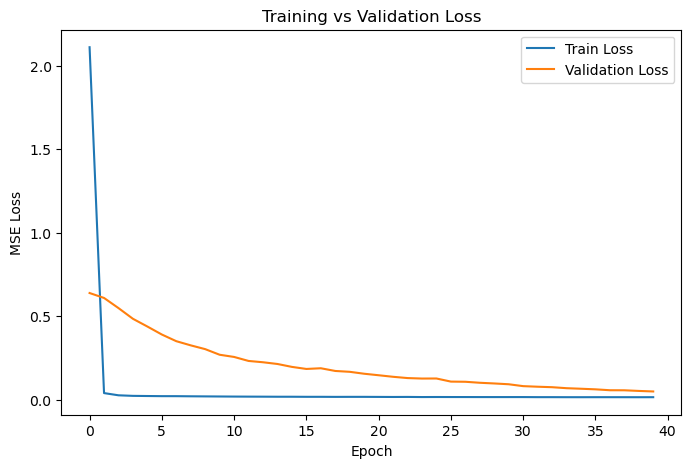

In [80]:
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.show()

The validation loss decreased rapidly during the initial epochs and stabilized after approximately 35 epochs. 

The small gap between training and validation loss indicates good generalization and limited overfitting. 

Therefore, early stopping is expected to reduce training time while maintaining similar predictive performance.

In [81]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_pred = model.predict(X_test).flatten()

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("RMSE:", rmse)
print("R²  :", r2)

337/337 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
MAE : 0.09341273621720841
RMSE: 0.2721589644905783
R²  : 0.9279208455374086


The baseline MLP achieved an R² score of 0.928, indicating that the model successfully captured the relationship between diamond characteristics and price.

Ok, Now let's experiment some hyperparameters and architectures.

Fisrt we define a function that use for build model in each experiment.

In [93]:
from tensorflow.keras.optimizers import Adam, SGD

def build_model(
    input_dim,
    hidden_layers=(64, 32),
    activation='relu',
    optimizer='adam',
    learning_rate=0.001,
    momentum=0.0,
    initializer='glorot_uniform'
):

    model = Sequential()

    for i, units in enumerate(hidden_layers):
        if i == 0:
            model.add(Dense(
                units,
                activation=activation,
                kernel_initializer=initializer,
                input_shape=(input_dim,)
            ))
        else:
            model.add(Dense(
                units,
                activation=activation,
                kernel_initializer=initializer
            ))

    model.add(Dense(1))

    if optimizer == 'adam':
        opt = Adam(learning_rate=learning_rate)

    elif optimizer == 'sgd':
        opt = SGD(
            learning_rate=learning_rate,
            momentum=momentum
        )

    model.compile(
        optimizer=opt,
        loss='mse',
        metrics=['mae']
    )

    return model

In [84]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def train_and_evaluate(
    X_train,
    y_train,
    X_test,
    y_test,
    batch_size=32,
    **model_params
):

    model = build_model(
        input_dim=X_train.shape[1],
        **model_params
    )

    history = model.fit(
        X_train,
        y_train,
        validation_split=0.2,
        epochs=40,
        batch_size=batch_size,
        verbose=0
    )

    y_pred = model.predict(X_test, verbose=0).flatten()

    return {
        "history": history,
        "MAE": mean_absolute_error(y_test, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, y_pred)),
        "R2": r2_score(y_test, y_pred)
    }

#### Optimizers

In [72]:
optimizer_experiments = {
    'Adam': {
        'optimizer': 'adam',
        'learning_rate': 0.001
    },

    'SGD': {
        'optimizer': 'sgd',
        'learning_rate': 0.001,
        'momentum': 0.0
    },

    'SGD + Momentum': {
        'optimizer': 'sgd',
        'learning_rate': 0.001,
        'momentum': 0.9
    }
}

results = []
histories = {}

for name, params in optimizer_experiments.items():

    result = train_and_evaluate(
        X_train,
        y_train,
        X_test,
        y_test,
        **params
    )

    results.append({
        'Optimizer': name,
        'MAE': result['MAE'],
        'RMSE': result['RMSE'],
        'R2': result['R2']
    })

    histories[name] = result['history']

    print(f'Finished: {name}')

c:\Users\kavoshrayan\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Finished: Adam


c:\Users\kavoshrayan\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Finished: SGD


c:\Users\kavoshrayan\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Finished: SGD + Momentum


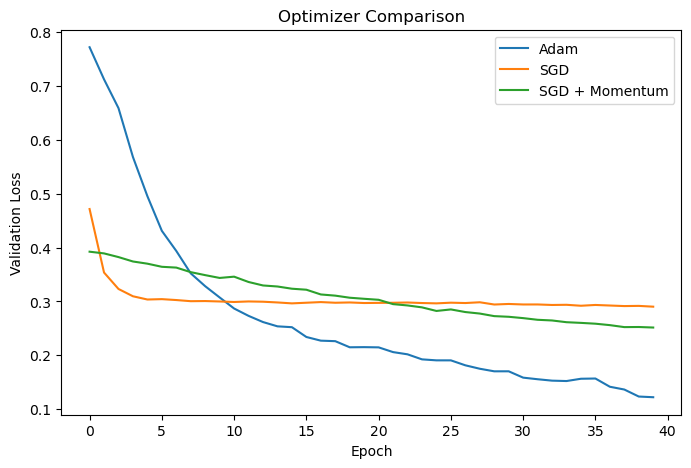

In [73]:
plt.figure(figsize=(8,5))

for name, history in histories.items():
    plt.plot(
        history.history['val_loss'],
        label=name
    )

plt.xlabel('Epoch')
plt.ylabel('Validation Loss')
plt.title('Optimizer Comparison')
plt.legend()
plt.show()

In [74]:
pd.DataFrame(results)

,Optimizer,MAE,RMSE,R2
0,Adam,0.089740,0.287847,0.919372
1,SGD,0.114871,0.547427,0.708381
2,SGD + Momentum,0.096477,0.479325,0.776425


- Adam achieved the best overall performance across all evaluation metrics.
- SGD converged quickly during the initial epochs but reached a plateau and showed limited further improvement.
- Adding momentum improved SGD considerably, resulting in lower error and higher R².

Among the tested optimizers, Adam provided the most effective and stable training process. The adaptive learning rate mechanism allowed it to converge faster and achieve better predictive performance than both SGD and SGD with Momentum.

#### Learning Rate

In [75]:
lr_experiments = {
    'LR = 0.0001': {
        'optimizer': 'adam',
        'learning_rate': 0.0001
    },

    'LR = 0.001': {
        'optimizer': 'adam',
        'learning_rate': 0.001
    },

    'LR = 0.01': {
        'optimizer': 'adam',
        'learning_rate': 0.01
    }
}

results = []
histories = {}

for name, params in lr_experiments.items():

    result = train_and_evaluate(
        X_train,
        y_train,
        X_test,
        y_test,
        **params
    )

    histories[name] = result['history']

    results.append({
        'Learning Rate': name,
        'MAE': result['MAE'],
        'RMSE': result['RMSE'],
        'R2': result['R2']
    })

c:\Users\kavoshrayan\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
c:\Users\kavoshrayan\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
c:\Users\kavoshrayan\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_

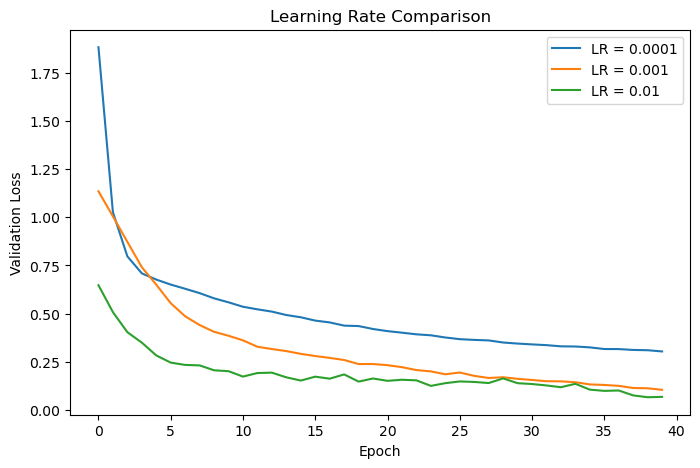

In [76]:
plt.figure(figsize=(8,5))

for name, history in histories.items():
    plt.plot(
        history.history['val_loss'],
        label=name
    )

plt.xlabel('Epoch')
plt.ylabel('Validation Loss')
plt.title('Learning Rate Comparison')
plt.legend()
plt.show()

In [77]:
pd.DataFrame(results)

,Learning Rate,MAE,RMSE,R2
0,LR = 0.0001,0.101187,0.583006,0.669242
1,LR = 0.001,0.105425,0.360742,0.873364
2,LR = 0.01,0.092607,0.236497,0.945573


- A learning rate of 0.0001 resulted in poor performance, indicating that the optimizer converged too slowly within the available training epochs.
- Increasing the learning rate to 0.001 significantly improved model performance.
- The best results were achieved with a learning rate of 0.01, which produced the lowest prediction error and highest R² score.
- For this problem, a larger learning rate enabled faster convergence and more effective optimization.

The learning rate had a substantial impact on model performance. Very small learning rates led to slow learning and underfitting, while a learning rate of 0.01 provided the best balance between convergence speed and predictive accuracy. Therefore, 0.01 was selected for subsequent experiments.

#### Batch size

Let's keep using the best settings we've found so far and then do the experiment.

In [86]:
batch_experiments = {
    'Batch 16': {
        'optimizer': 'adam',
        'learning_rate': 0.01,
        'batch_size': 16
    },
    'Batch 32': {
        'optimizer': 'adam',
        'learning_rate': 0.01,
        'batch_size': 32
    },
    'Batch 128': {
        'optimizer': 'adam',
        'learning_rate': 0.01,
        'batch_size': 128
    }
}

results = []
histories = {}

for name, params in batch_experiments.items():
    params = params.copy()
    batch_size = params.pop('batch_size')

    result = train_and_evaluate(
        X_train,
        y_train,
        X_test,
        y_test,
        batch_size=batch_size,
        **params
    )

    histories[name] = result['history']

    results.append({
        'Batch Size': name,
        'MAE': result['MAE'],
        'RMSE': result['RMSE'],
        'R2': result['R2']
    })

c:\Users\kavoshrayan\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
c:\Users\kavoshrayan\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
c:\Users\kavoshrayan\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_

In [87]:
pd.DataFrame(results)

,Batch Size,MAE,RMSE,R2
0,Batch 16,0.113808,0.216393,0.954433
1,Batch 32,0.087559,0.254769,0.936838
2,Batch 128,0.101522,0.414704,0.832644


- Batch size 16 achieved the best RMSE and R² scores, indicating the strongest overall predictive performance.
- Batch size 32 produced the lowest MAE but slightly worse RMSE and R² values.
- Batch size 128 resulted in substantially poorer performance across most metrics.

Smaller batch sizes perform more frequent parameter updates and introduce stochasticity into the optimization process. This noise can improve generalization and help the model avoid poor local minima.

In contrast, the large batch size of 128 produced smoother gradient estimates but resulted in weaker generalization performance and higher prediction error.

#### Early Stopping

In [92]:
# without early stopping
model_no_es = build_model(
    input_dim=X_train.shape[1],
    optimizer='adam',
    learning_rate=0.01
)

history_no_es = model_no_es.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    verbose=0
)

c:\Users\kavoshrayan\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


We define an early stopping that : 
- wtches validation loss to detect when the model stops improving on unseen data.
- waits 10 epochs of no improvement before stopping, giving the model time to escape plateaus.
- rolls back to the best model found instead of keeping the possibly overfitted final model.

In [94]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

model_es = build_model(
    input_dim=X_train.shape[1],
    optimizer='adam',
    learning_rate=0.01
)

history_es = model_es.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=0
)

c:\Users\kavoshrayan\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


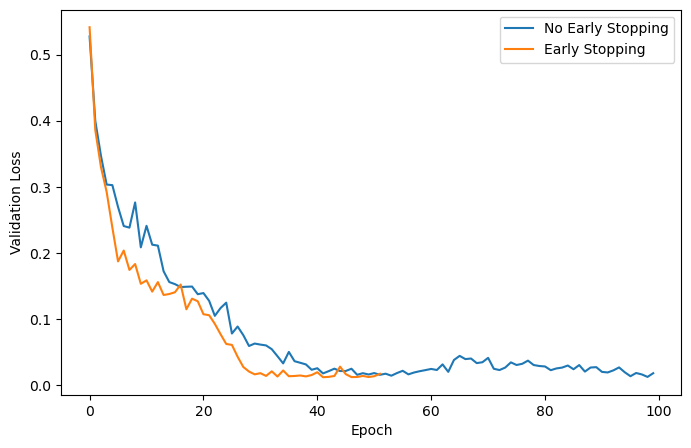

In [95]:
plt.figure(figsize=(8,5))

plt.plot(
    history_no_es.history['val_loss'],
    label='No Early Stopping'
)

plt.plot(
    history_es.history['val_loss'],
    label='Early Stopping'
)

plt.xlabel('Epoch')
plt.ylabel('Validation Loss')
plt.legend()
plt.show()

In [96]:
# Compare Epochs Used
print("No ES:", len(history_no_es.history['loss']))
print("With ES:", len(history_es.history['loss']))

No ES: 100
With ES: 52


- The model trained with Early Stopping automatically terminated after 52 epochs.
- The model without Early Stopping completed all 100 epochs.
- This reduced the training duration by approximately 48%.
- Validation loss stopped improving after roughly 52 epochs, indicating that additional training was unlikely to provide substantial benefits.

Early Stopping serves as an effective mechanism for improving training efficiency and reducing the risk of overfitting.

#### Learning Rate Scheduling

In [97]:
# Fixed Learning Rate
model_fixed = build_model(
    input_dim=X_train.shape[1],
    optimizer='adam',
    learning_rate=0.01
)

history_fixed = model_fixed.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    verbose=0
)

c:\Users\kavoshrayan\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [98]:
from tensorflow.keras.callbacks import ReduceLROnPlateau

# Learning Rate Scheduling
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5
)

model_sched = build_model(
    input_dim=X_train.shape[1],
    optimizer='adam',
    learning_rate=0.01
)

history_sched = model_sched.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[reduce_lr],
    verbose=0
)

c:\Users\kavoshrayan\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [99]:
def evaluate(model):
    y_pred = model.predict(X_test, verbose=0).flatten()

    return {
        "MAE": mean_absolute_error(y_test, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, y_pred)),
        "R2": r2_score(y_test, y_pred)
    }

fixed_metrics = evaluate(model_fixed)
sched_metrics = evaluate(model_sched)

print(fixed_metrics)
print(sched_metrics)

{'MAE': 0.08675233775910259, 'RMSE': np.float64(0.3026410616121687), 'R2': 0.9108707813864286}
{'MAE': 0.08503771497124692, 'RMSE': np.float64(0.26866202393376976), 'R2': 0.929761219936157}


- Learning rate scheduling achieved lower prediction error and higher R².
- The largest improvement was observed in RMSE, indicating a reduction in large prediction errors.
- Dynamically reducing the learning rate allowed the optimizer to make finer parameter updates during later stages of training.

Learning rate scheduling improved both optimization and generalization performance. By decreasing the learning rate when validation loss plateaued, the model achieved a better final solution than training with a fixed learning rate.

### Architecture Experiments 

#### Depth (Number of Hidden Layers)

In [102]:
depth_experiments = {
    '1 Hidden Layer': {
        'hidden_layers': (64,),
        'learning_rate': 0.01,
        'batch_size': 16
    },

    '2 Hidden Layers': {
        'hidden_layers': (64, 32),
        'learning_rate': 0.01,
        'batch_size': 16
    },

    '3 Hidden Layers': {
        'hidden_layers': (128, 64, 32),
        'learning_rate': 0.01,
        'batch_size': 16
    }
}

results = []
histories = {}

for name, params in depth_experiments.items():
    params = params.copy()
    batch_size = params.pop('batch_size')

    result = train_and_evaluate(
        X_train,
        y_train,
        X_test,
        y_test,
        batch_size=batch_size,
        **params
    )

    histories[name] = result['history']

    results.append({
        'hidden layer': name,
        'MAE': result['MAE'],
        'RMSE': result['RMSE'],
        'R2': result['R2']
    })

c:\Users\kavoshrayan\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
c:\Users\kavoshrayan\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
c:\Users\kavoshrayan\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_

In [103]:
pd.DataFrame(results)

,hidden layer,MAE,RMSE,R2
0,1 Hidden Layer,0.102703,0.320961,0.899754
1,2 Hidden Layers,0.089435,0.175219,0.970124
2,3 Hidden Layers,0.081908,0.132248,0.982981


Increasing the number of hidden layers consistently improved performance. Both loss and MAE decreased, while R² increased substantially. The three-layer architecture achieved the best results, indicating that the regression problem benefits from a deeper network capable of modeling more complex nonlinear relationships.

The improvement from two to three hidden layers was smaller than the improvement from one to two layers, suggesting diminishing returns as network depth increases.

#### Width (Neurons per Layer)

We keep depth fixed.

In [104]:
width_experiments = {
    'Small': {
        'hidden_layers': (32, 16),
        'learning_rate': 0.01,
        'batch_size': 16
    },

    'Medium': {
        'hidden_layers': (64, 32),
        'learning_rate': 0.01,
        'batch_size': 16
    },

    'Large': {
        'hidden_layers': (256, 128),
        'learning_rate': 0.01,
        'batch_size': 16
    }
}

results = []
histories = {}

for name, params in width_experiments.items():
    params = params.copy()
    batch_size = params.pop('batch_size')

    result = train_and_evaluate(
        X_train,
        y_train,
        X_test,
        y_test,
        batch_size=batch_size,
        **params
    )

    histories[name] = result['history']

    results.append({
        'hidden layer': name,
        'MAE': result['MAE'],
        'RMSE': result['RMSE'],
        'R2': result['R2']
    })

c:\Users\kavoshrayan\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
c:\Users\kavoshrayan\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
c:\Users\kavoshrayan\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_

In [105]:
pd.DataFrame(results)

,hidden layer,MAE,RMSE,R2
0,Small,0.091826,0.455033,0.798512
1,Medium,0.088046,0.387267,0.854056
2,Large,0.084729,0.125590,0.984651


Increasing the number of neurons consistently improved model performance. The Large architecture achieved the lowest loss and MAE while obtaining the highest R² score.

These results suggest that the regression problem benefits from increased model capacity. The smaller networks were likely unable to fully capture the nonlinear relationships in the data, whereas the Large model provided sufficient representational power to model the target variable accurately.

#### Activation Functions

We use a fixed Xavier (Glorot) initialization for all models to isolate the effect of the activation function.


In [ ]:
from tensorflow.keras.layers import Dense, LeakyReLU

activation_experiments = {
    'ReLU': {
        'activation': 'relu',
    },

    'Tanh': {
        'activation': 'tanh',
    },

    'Sigmoid': {
        'activation': 'sigmoid',
    }
}

results = []
histories = {}

for name, params in activation_experiments.items():
    result = train_and_evaluate(
        X_train,
        y_train,
        X_test,
        y_test,
        **params
    )

    histories[name] = result['history']

    results.append({
        'activation': name,
        'MAE': result['MAE'],
        'RMSE': result['RMSE'],
        'R2': result['R2']
    })

c:\Users\kavoshrayan\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
c:\Users\kavoshrayan\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
c:\Users\kavoshrayan\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_

In [108]:
pd.DataFrame(results)

,activation,MAE,RMSE,R2
0,ReLU,0.092600,0.319407,0.900722
1,Tanh,0.080599,0.173200,0.970808
2,Sigmoid,0.082697,0.108413,0.988563


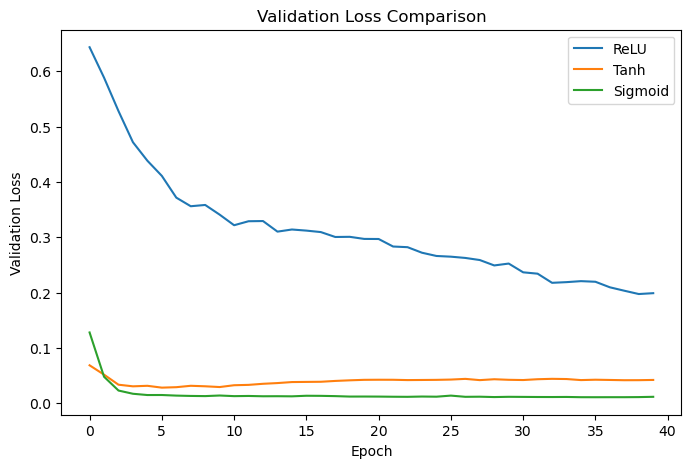

In [109]:
plt.figure(figsize=(8,5))

for name, history in histories.items():
    plt.plot(history.history['val_loss'], label=name)

plt.xlabel('Epoch')
plt.ylabel('Validation Loss')
plt.title('Validation Loss Comparison')
plt.legend()
plt.show()

Among the tested activations, Sigmoid achieved the best performance with an RMSE of 0.108 and an R² of 0.989. Tanh also performed strongly, while ReLU produced substantially higher validation loss and lower predictive accuracy.

These results indicate that, for this particular regression task and network architecture, smoother activation functions provided better predictive performance than ReLU.

#### Weight Initialization

Let's keep using the best 'learning_rate', 'batch_size' we've found so far and then do the experiment.

We fix 'relue' as activation function for all.

In [111]:
init_experiments = {

    'Random Normal': {
        'initializer': 'random_normal',
        'learning_rate':0.01,
        'batch_size':16
    },

    'Xavier': {
        'initializer': 'glorot_uniform',
        'optimizer':'adam',
        'learning_rate':0.01,
        'batch_size':16
    },

    'He': {
        'initializer': 'he_normal',
        'optimizer':'adam',
        'learning_rate':0.01,
        'batch_size':16
    }
}

results = []
histories = {}

for name, params in init_experiments.items():
    params = params.copy()
    batch_size = params.pop('batch_size')

    result = train_and_evaluate(
        X_train,
        y_train,
        X_test,
        y_test,
        batch_size=batch_size,
        **params
    )

    histories[name] = result['history']

    results.append({
        'Initialization': name,
        'MAE': result['MAE'],
        'RMSE': result['RMSE'],
        'R2': result['R2']
    })

c:\Users\kavoshrayan\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
c:\Users\kavoshrayan\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
c:\Users\kavoshrayan\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_

In [112]:
pd.DataFrame(results)

,Initialization,MAE,RMSE,R2
0,Random Normal,0.107602,0.198773,0.961552
1,Xavier,0.091158,0.346810,0.882956
2,He,0.106570,0.196084,0.962585


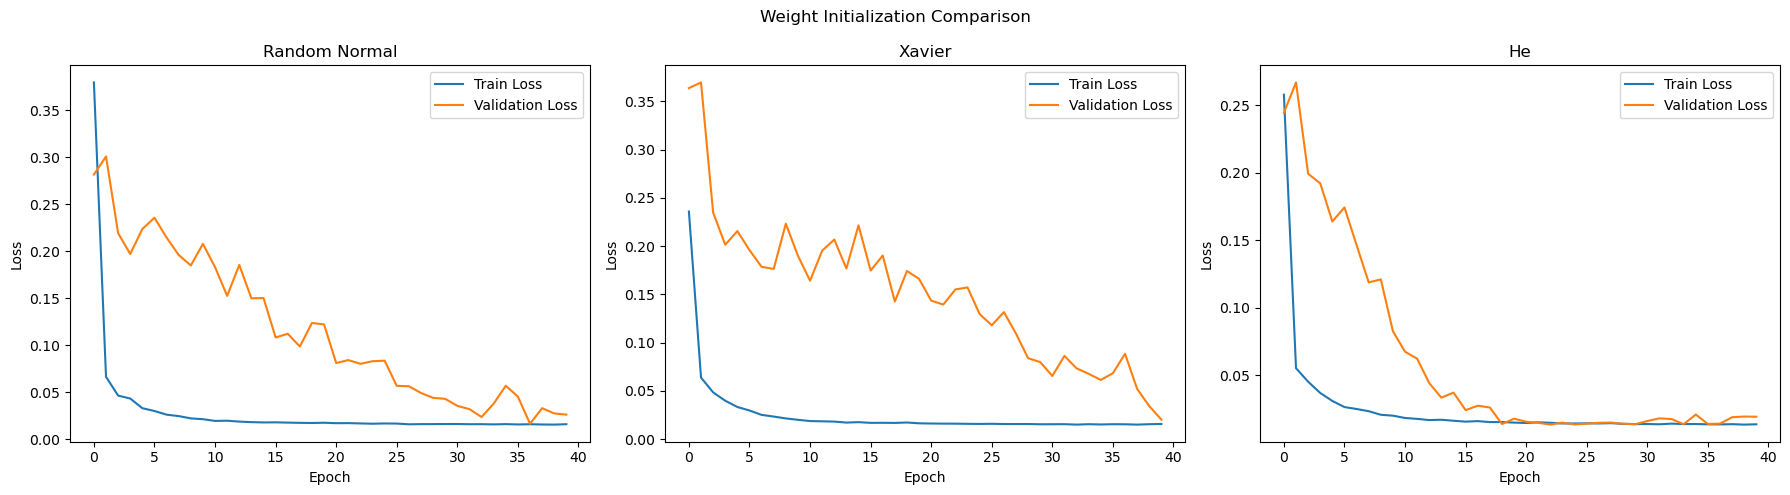

In [113]:
fig, axes = plt.subplots(1, len(histories), figsize=(18, 5))

for ax, (name, history) in zip(axes, histories.items()):

    ax.plot(history.history['loss'], label='Train Loss')
    ax.plot(history.history['val_loss'], label='Validation Loss')

    ax.set_title(name)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.legend()

plt.suptitle('Weight Initialization Comparison')
plt.tight_layout()
plt.show()

- He initialization achieved the best overall performance, producing the lowest RMSE and highest R².
- Random Normal performed similarly to He but converged slightly less effectively.
- Xavier initialization resulted in significantly higher validation loss and poorer predictive performance.

He initialization is specifically designed for ReLU-based neural networks and helps maintain stable activation and gradient magnitudes during training. This led to faster convergence and better generalization. Xavier initialization, while effective for Tanh and Sigmoid activations, was less suitable for the ReLU network used in this experiment.

## Discussion Questions

#### Why are neural networks so powerful?

Neural networks are powerful for several compounding reasons:
- Unlike traditional ML methods that require hand-crafted features, neural networks learn representations directly from raw data. Each layer transforms the input into increasingly abstract, task-relevant features — no domain expert needed.

- A network with even a single hidden layer and enough neurons can approximate any continuous function to arbitrary precision. 

- Real-world data has hierarchical structure (pixels → edges → shapes → objects). Neural networks naturally exploit this by stacking transformations, learning a hierarchy of concepts that mirrors the structure of the problem.

- Scalability. Performance tends to improve predictably with more data and more compute — a property few classical methods share. This has made them the engine of modern AI scaling.
- Activation functions (ReLU, sigmoid, tanh) let networks model complex, non-linear decision boundaries that linear models fundamentally cannot.

#### Why does training become more difficult as we go deeper?

Depth introduces several compounding instabilities during backpropagation:

- Vanishing gradients. When gradients are backpropagated through many layers, they are multiplied by weights and activation derivatives repeatedly. If these values are < 1 , the gradient shrinks exponentially toward the input layers — early layers learn almost nothing.

- Exploding gradients. The reverse problem: if weights are large, gradients grow exponentially, causing unstable, divergent updates.

- Bad starting weights push activations into saturation zones immediately, killing gradients before training even meaningfully begins.

- Internal covariate shift. As weights update, the distribution of inputs to each layer shifts constantly, forcing every layer to chase a moving target. Batch normalization was designed specifically to address this.

- Optimization landscape complexity. Deeper networks have a higher-dimensional, non-convex loss surface with more saddle points and sharp minima that are harder for gradient descent to navigate.

#### (Optional) If MLPs can approximate any function with a single hidden layer (UniversalApproximation Theorem), what unique benefits does depth provide that cannot be achievedsimply by increasing width?

- Width adds more detectors at the same abstraction level and scales quantity of representation.
- Depth enables hierarchical composition — building complex concepts from simple ones and scales quality and abstraction.
- Crucially, some functions require exponentially more neurons to represent in a shallow network than a deep one, so depth can be exponentially more efficient, not just convenient.